## 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [1]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [2]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [3]:
print(iris.keys())

print(iris.data[:10])

print(iris.data.dtype)

print(iris.target)
print(iris.target_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
float64
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [4]:
iris['feature_names'][:2]

['sepal length (cm)', 'sepal width (cm)']

In [5]:
# we only take the first two features. 
X = iris.data[:, :2] 
print(X.shape)

(150, 2)


In [6]:
#以下是組成 pandas DataFrame (也可以不用這種做)
x = pd.DataFrame(iris.data[:, :2], columns=iris['feature_names'][:2])
x.head(10)

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
5,5.4,3.9
6,4.6,3.4
7,5.0,3.4
8,4.4,2.9
9,4.9,3.1


In [7]:
y = pd.DataFrame(iris['target'], columns=['target'])
y.head(10)

,target
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [8]:
print("target_names:" + str(iris['target_names']))

target_names:['setosa' 'versicolor' 'virginica']


_IncompleteInputError: incomplete input (149104261.py, line 1)

In [10]:
#建立Target欄位與資料
y = pd.DataFrame(iris['target'], columns=['target'])
y.head(10)

,target
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [11]:
#合併資料特徵欄位與目標欄位
df_combined = pd.concat([x, y], axis=1)
df_combined.head(10)

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
5,5.4,3.9,0
6,4.6,3.4,0
7,5.0,3.4,0
8,4.4,2.9,0
9,4.9,3.1,0


In [12]:
x1 = pd.DataFrame(iris.data, columns=iris['feature_names'])
y1 = pd.DataFrame(iris['target'], columns=['target'])
iris_combined = pd.concat([x1, y1], axis=1)

In [13]:
iris_combined.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [14]:
#只選擇目標為0與1的資料
iris_combined.loc[iris_combined['target'].isin([0, 1]), :]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


## 切分訓練集與測試集
> train_test_split()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,               # 你的特徵資料
    y,               # 你的標籤資料
    test_size=0.2,   # 測試集佔 20% 
    stratify=y       # 依照 y 的比例進行分層抽樣
)

In [16]:
X_train.head()

,sepal length (cm),sepal width (cm)
32,5.2,4.1
7,5.0,3.4
146,6.3,2.5
78,6.0,2.9
115,6.4,3.2


In [17]:
X_test.head()

,sepal length (cm),sepal width (cm)
94,5.6,2.7
113,5.7,2.5
107,7.3,2.9
137,6.4,3.1
132,6.4,2.8


# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [20]:
def norm_stats(dfs):
    # axis=0 表示沿著列計算，會回傳每一欄的統計值 (Series)
    minimum = np.min(dfs, axis=0)
    maximum = np.max(dfs, axis=0)
    mu = np.mean(dfs, axis=0)
    sigma = np.std(dfs, axis=0)
    return (minimum, maximum, mu, sigma)


def z_score(col, stats):
    m, M, mu, s = stats
    df = pd.DataFrame()
    for c in col.columns:
        df[c] = (col[c]-mu[c])/s[c]
    return df

In [21]:
stats = norm_stats(X_train)
arr_x_train = np.array(z_score(X_train, stats))
arr_y_train = np.array(y_train)
arr_x_train[:5]

array([[-0.82062415,  2.34960377],
       [-1.06022244,  0.7436907 ],
       [ 0.49716645, -1.32105468],
       [ 0.13776902, -0.40339007],
       [ 0.6169656 ,  0.28485839]])

## use sklearn

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.885      3.07583333]
[0.8347305 0.4358891]


In [24]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[-0.82062415,  2.34960377],
       [-1.06022244,  0.7436907 ],
       [ 0.49716645, -1.32105468],
       [ 0.13776902, -0.40339007],
       [ 0.6169656 ,  0.28485839]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [25]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[-0.34142756 -0.86222238]
 [-0.22162842 -1.32105468]
 [ 1.69515791 -0.40339007]
 [ 0.6169656   0.05544224]
 [ 0.6169656  -0.63280622]
 [-1.89881645 -0.17397392]
 [ 0.37736731 -0.63280622]
 [-0.700825    1.43193916]
 [ 0.49716645  0.7436907 ]
 [-0.94042329  0.51427454]]


you can also use fit_transform method (i.e., fit and then transform)    

In [26]:
X_train_std = sc.fit_transform(X_train)  
X_test_std = sc.fit_transform(X_test)
print(X_test_std[:10])


[[-0.10034106 -0.67398788]
 [ 0.03053858 -1.14974404]
 [ 2.1246128  -0.19823173]
 [ 0.94669605  0.27752442]
 [ 0.94669605 -0.43610981]
 [-1.80177636  0.03964635]
 [ 0.68493678 -0.43610981]
 [-0.49297997  1.70479288]
 [ 0.81581641  0.99115865]
 [-0.75473925  0.75328058]]


In [27]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 1.0


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


49.6985219089125
29.466042336570396


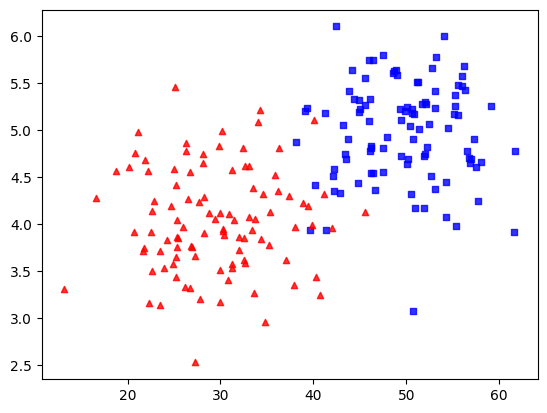

In [28]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

In [29]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [30]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [31]:
minmax_norm(x_val[:10])

array([0.64756543, 0.92520501, 0.63171908, 0.74956264, 0.2645497 ,
       0.        , 0.50805158, 0.24412347, 0.10726612, 1.        ])

In [32]:
from sklearn.preprocessing import MinMaxScaler
x_val=x_val.reshape(-1, 1)
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.transform(x_val)[:10])

[61.70955172]
[[0.78322866]
 [0.88836687]
 [0.77722787]
 [0.82185357]
 [0.63818598]
 [0.53800472]
 [0.73039672]
 [0.63045085]
 [0.57862489]
 [0.91669068]]
